In [411]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [412]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Read the data

In [413]:
df=pd.read_csv('Churn_Modelling.csv')
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


# Data Description:
* **Customer ID:** A unique identifier for each customer.
* **Surname:** The customer's surname or last name.
* **Credit Score:** A numerical value representing the customer's credit score.
* **Geography:** The country where the customer resides.
* **Gender:** The customer's gender.
* **Age:** The customer's age.
* **Tenure:** The number of years the customer has been with the bank.
* **Balance:** The customer's account balance.
* **NumOfProducts:** The number of bank products the customer uses (e.g., savings account, credit card).
* **HasCrCard:** Whether the customer has a credit card.
* **IsActiveMember:** Whether the customer is an active member.
* **EstimatedSalary:** The estimated salary of the customer.
* **Exited:** Whether the customer has churned (Target Variable).

# Data Exploration

In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [415]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [416]:
null_counts=df.isnull().sum()
null_counts

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [417]:
duplicate_counts=df.duplicated().sum()
duplicate_counts

np.int64(0)

In [418]:
# how imbalanced is the target?
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [419]:
drop_cols=['RowNumber','CustomerId','Surname']
df.drop(drop_cols, axis=1, inplace=True)

In [420]:
# select num_feature and cat_features
num_features=df.select_dtypes(include=['int64','float64']).columns
cat_features=df.select_dtypes(include=['object']).columns
print('Numerical features:', num_features)
print('Categorical features:', cat_features)

Numerical features: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
Categorical features: Index(['Geography', 'Gender'], dtype='object')


# EDA

In [421]:
fig = px.pie(df, names='Exited', title='Customer outflow', labels=['Not Exited', 'Exited'], 
             width=800, height=400, hole=0.3)

fig.update_traces(textposition='inside', textinfo='percent+label', pull=[0, 0.1], marker=dict(colors=['#63ace5', '#ff7f0e']))
fig.update_layout(showlegend=False)

fig.show()

fig_count = px.histogram(df, x='Exited', labels={'Exited': 'Target'}, 
                         width=800, height=400, color_discrete_sequence=['#63ace5'])

fig_count.update_layout(showlegend=False)
fig_count.show()

In [422]:
#use plotly boxplot in numerical features to see `outliers`
for col in num_features:
    fig = px.box(df, y=col, title=f'Box Plot of {col}', width=800, height=400)
    fig.show()

In [423]:
#usung plptly to Distribution of Age by Churn Status
fig = px.histogram(df, x='Age', color='Exited', nbins=20, width=800, height=400)
fig.show()

In [424]:
#using plotly to Churn Count by Geography
fig = px.histogram(df, x='Geography', color='Exited', width=800, height=400)
fig.show()

In [425]:
corr_matrix = df.corr(numeric_only=True)

# 3. رسم الـ Heatmap باستخدام Plotly
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu',
    zmin=-1, 
    zmax=1,
    text=np.round(corr_matrix.values, 2), #
    texttemplate="%{text}",
))

fig.update_layout(
    title='Correlation Heatmap (Bank Churn Features)',
    width=800, 
    height=700,
    xaxis_showgrid=False,
    yaxis_showgrid=False
)

fig.show()

In [426]:
#use plotly in column tenure and Exited
fig = px.histogram(df, x='Tenure', color='Exited', nbins=20, width=800, height=400)
fig.show()

In [427]:
#use plotly in column balance and Exited
fig = px.histogram(df, x='Balance', color='Exited', nbins=20, width=800, height=400)
fig.show()

In [428]:
#use plotly in column NumOfProducts and Exited
fig = px.histogram(df, x='NumOfProducts', color='Exited', nbins=20, width=800, height=400)
fig.show()

In [429]:
#using plotly in column gender and Exited by color (red and blue)
fig =px.pie(df, names='Gender', color='Exited', title='Gender Distribution by Churn Status', width=800, height=400, hole=0.4)
fig.show()

# Preprocessing and Feature engineering


# 1-Encoding

In [430]:
# apply label encoding for column gender
label_encoder=LabelEncoder()
df['Gender']=label_encoder.fit_transform(df['Gender'])

#--------------------------------



In [431]:
# apply one hot encoding for column Geography

one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')


geography_encoded = one_hot_encoder.fit_transform(df[['Geography']])


df = pd.concat([
    df.reset_index(drop=True), # add index column to avoid index mismatch and null values
    pd.DataFrame(geography_encoded, columns=one_hot_encoder.get_feature_names_out(['Geography']))
], axis=1)


df.drop('Geography', axis=1, inplace=True)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0


# Data Splitting and Scaling

In [432]:
Scaler = StandardScaler()

# spilt data into features and target
x=df.drop('Exited', axis=1)
y=df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
x_train[numeric_cols] = Scaler.fit_transform(x_train[numeric_cols])
x_test[numeric_cols] = Scaler.transform(x_test[numeric_cols])

print(f"Training set shape: x_train={x_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: x_test={x_test.shape}, y_test={y_test.shape}")




Training set shape: x_train=(8000, 11), y_train=(8000,)
Test set shape: x_test=(2000, 11), y_test=(2000,)


# Model Building and Training

In [433]:
# apply Rondom forest classifier
rf=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') 
rf.fit(x_train, y_train)

y_pred=rf.predict(x_test)
print(classification_report(y_test, y_pred))    

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Accuracy: 0.866
Precision: 0.7659574468085106
Recall: 0.4580152671755725
F1 Score: 0.5732484076433121


In [434]:
cm=confusion_matrix(y_test, y_pred)
px.imshow(cm, text_auto=True, color_continuous_scale='Blues', title='Confusion Matrix', width=800, height=600).show()
#select fp,tn,tp,fn
fp = cm[0, 1]
tn = cm[0, 0]
tp = cm[1, 1]
fn = cm[1, 0]
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")  
print(f"True Positive (TP): {tp}")
print(f"False Negative (FN): {fn}")


False Positive (FP): 55
True Negative (TN): 1552
True Positive (TP): 180
False Negative (FN): 213


In [435]:
#apply roc_cirve
from sklearn.metrics import auc


y_prob = rf.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Guess'))
fig.update_layout(
    title=f'ROC Curve (AUC = {roc_auc:.2f})',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    width=800,
    height=600
)

In [436]:
# apply svm
svm=SVC( random_state=42,  probability=True)

svm.fit(x_train, y_train)
y_pred_svm=svm.predict(x_test)
print(classification_report(y_test, y_pred_svm))

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.77      0.38      0.51       393

    accuracy                           0.86      2000
   macro avg       0.82      0.68      0.71      2000
weighted avg       0.85      0.86      0.84      2000

Accuracy: 0.856
Precision: 0.7692307692307693
Recall: 0.3816793893129771
F1 Score: 0.5102040816326531


# Models Training

In [437]:

knn = KNeighborsClassifier().fit(x_train, y_train)
dt  = DecisionTreeClassifier(random_state=42).fit(x_train, y_train)
rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(x_train, y_train)
svm = SVC(probability=True, random_state=42).fit(x_train, y_train)
nb  = GaussianNB().fit(x_train, y_train)

print('Model training')

Model training


# Model Evaluation

In [438]:

def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Confusion Matrix': cm,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'y_prob'   : y_prob,
    }


models = {
    'K-Nearest Neighbors': knn,
    'Decision Tree'      : dt,
    'Random Forest'      : rf,
    'SVM'                : svm,
    'Naive Bayes'        : nb,
}


results = {name: evaluate_model(m, x_test, y_test) for name, m in models.items()}


summary_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall'   : f"{r['Recall']:.4f}",
        'F1-Score' : f"{r['F1-Score']:.4f}",
        'ROC-AUC'  : f"{r['ROC-AUC']:.4f}",
    }
    for name, r in results.items()
])

print(summary_df.to_string(index=False))

              Model Accuracy Precision Recall F1-Score ROC-AUC
K-Nearest Neighbors   0.8300    0.6109 0.3715   0.4620  0.7604
      Decision Tree   0.7840    0.4550 0.5013   0.4770  0.6772
      Random Forest   0.8665    0.7647 0.4631   0.5769  0.8572
                SVM   0.8560    0.7692 0.3817   0.5102  0.8248
        Naive Bayes   0.8335    0.6351 0.3588   0.4585  0.8044


# Confusion Matrix

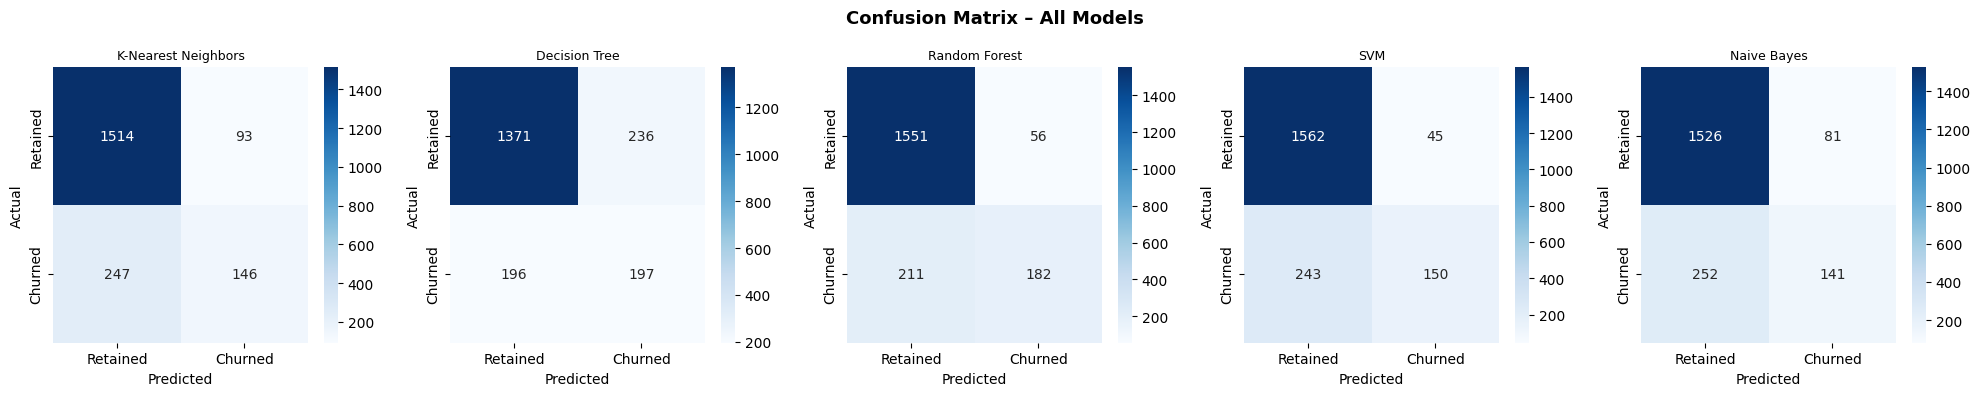

In [439]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r['Confusion Matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'], ax=ax)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC-AUC Curve

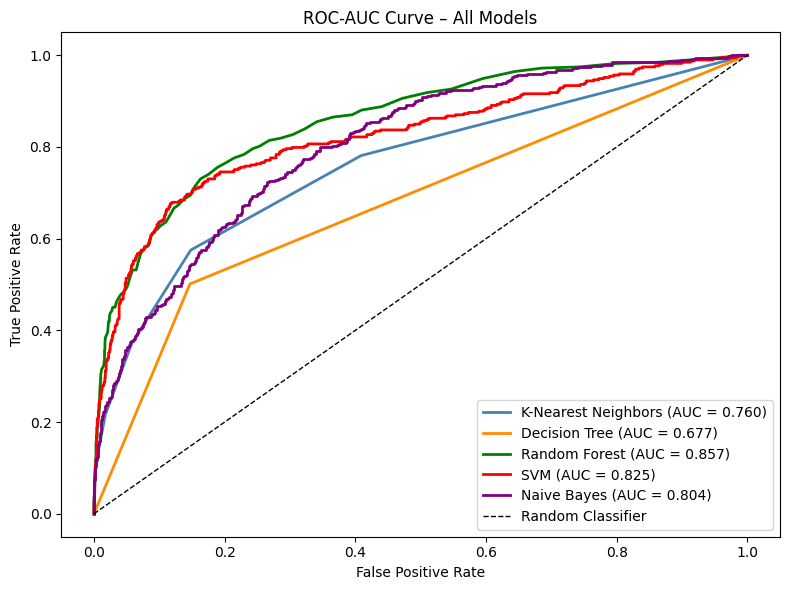

In [440]:
plt.figure(figsize=(8, 6))
colors = ['steelblue','darkorange','green','red','purple']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {r['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve – All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Feature Importance

In [442]:
feature_names = x_train.columns.tolist()
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

px.bar(fi_df, x='Feature', y='Importance', title='Feature Importance from Random Forest', width=1400, height=500, color='Importance').show()

print(fi_df.to_string(index=False))


          Feature  Importance
              Age    0.239783
  EstimatedSalary    0.146638
      CreditScore    0.144214
          Balance    0.138613
    NumOfProducts    0.130255
           Tenure    0.082427
   IsActiveMember    0.041110
Geography_Germany    0.025711
           Gender    0.019258
        HasCrCard    0.018722
  Geography_Spain    0.013268
